In [1]:
import numpy as np
import cupy as cp
from scipy.special import factorial
from itertools import combinations_with_replacement, combinations
import matplotlib.pyplot as plt
import sys, os, time

## q2

In [16]:
N = 20
K = 1
S = 1
dir_data = f'data/N{N}_K{K}_highT_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')

q2 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    # history = cp.random.rand(*history.shape)*2 - 1
    # history = cp.random.rand(20000, 100, 1, N, 3)*2 - 1
    q2_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            out = history[:,j,k,:,:] # working with one sample 
            out = cp.einsum('...ac,...bc->...abc', out, out) # taking outer product of spins across sites
            out = out.reshape(out.shape[0], out.shape[1]**2, out.shape[-1]) # flattening outer product matrix
            out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
            out = cp.mean(out**2, axis=0) # taking permutation average of squared quadruple products
            q2_T.append(out)

            subprogress += 1
            print(f'\rq2 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1]/history.shape[2], 2)}%', end='')
    q2_T = cp.mean(cp.array(q2_T), axis=0)
    q2.append(q2_T)
q2 = cp.array(q2).get()
cp.save(f'{dir_data}/q2.npy', q2) # saving q2
print('; Done.')

q2 Progress: 100.0%; Subprogress: 100.0%; Done.


In [3]:
q2[:,2], ((1/3)**2*N/N**2)

(array([0.99981655, 0.63726166, 0.36789282, 0.12145557, 0.04207388,
        0.02262073, 0.01146044, 0.00711498, 0.00576026, 0.00495467,
        0.00448122]),
 0.002777777777777778)

## q2 (combinations)

In [5]:
N = 10
K = 1
S = 1

dir_data = f'data/N{N}_K{K}_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')

combination_idcs = np.array(list(combinations_with_replacement(np.arange(N), 2)))

repetitions = factorial(2)*np.ones(combination_idcs.shape[0])
for i, combination in enumerate(combination_idcs):
    repetitions[i] /= np.prod(factorial(np.unique(combination, return_counts=True)[1]))
repetitions = repetitions.astype(int)
repetitions_broadcasted = cp.broadcast_to(cp.array(repetitions)[:,None], (repetitions.shape[0], 3))

# mask = np.zeros(combination_idcs.shape[0]).astype(int)

# for i, combination in enumerate(combination_idcs):
#     if np.prod(np.unique(combination_idcs[i], return_counts=True)[1]) == 2:
#         mask[i] = 1

# for i, combination in enumerate(combination_idcs):
#     if np.prod(np.unique(combination_idcs[i], return_counts=True)[1]) == 1:
#         mask[i] = 1

# mask_broadcasted = cp.broadcast_to(cp.array(mask)[:, None], (mask.shape[0], 3))

q2 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    # history = cp.random.rand(*history.shape)*2 - 1
    # history = cp.random.rand(100000, 1, 1, N, 3)*2 - 1
    q2_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            sample = history[:,j,k,:,:] # working with one sample 
            out = cp.ones((history.shape[0], combination_idcs.shape[0], 3)) # creating blank of ones
            for l in range(2): # listing all combinations of quadruple products
                out *= sample[:, combination_idcs[:,l], :]
            out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
            out = out**2*repetitions_broadcasted #*mask_broadcasted # taking permutation average of squared quadruple products
            out = cp.sum(out, axis=0)/N**2
            q2_T.append(out)

            subprogress += 1
            print(f'\rq2 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1]/history.shape[2], 2)}%', end='')
    saved = cp.copy(cp.array(q2_T))
    q2_T = cp.mean(cp.array(q2_T), axis=0)
    q2.append(q2_T)
q2 = cp.array(q2).get()
# cp.save(f'{dir_data}/q2_test.npy', q2) # saving q2
print('; Done.')

q2 Progress: 100.0%; Subprogress: 100.0%; Done.


In [5]:
q2[:,2], ((1/3)**2*N/N**2)

(array([0.99988291, 0.65458502, 0.35985972, 0.14535907, 0.0486647 ,
        0.02055159, 0.0118336 , 0.00870175, 0.00729667, 0.00641027,
        0.00591607]),
 0.0037037037037037034)

## q4 (combinations; time-step parallel)

In [ ]:
N = 20
K = 1
S = 1
combination_idcs = np.array(list(combinations_with_replacement(np.arange(N), 4)))

dir_data = f'data/N{N}_K{K}_highTmoreSamples_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')

repetitions = factorial(4)*np.ones(combination_idcs.shape[0])
for i, combination in enumerate(combination_idcs):
    repetitions[i] /= np.prod(factorial(np.unique(combination, return_counts=True)[1]))
repetitions = repetitions.astype(int)
repetitions_broadcasted = cp.broadcast_to(cp.array(repetitions)[:,None], (repetitions.shape[0], 3))

# mask = np.zeros(combination_idcs.shape[0]).astype(int)

# for i, combination in enumerate(combination_idcs):
#     if np.prod((np.unique(np.unique(combination_idcs[i], return_counts=True)[1]) == np.array([2])).astype(int)):
#         mask[i] = 1

# for i, combination in enumerate(combination_idcs):
#     if np.prod(np.unique(combination_idcs[i], return_counts=True)[1]) == 1:
#         mask[i] = 1

# mask_broadcasted = cp.broadcast_to(cp.array(mask)[:, None], (mask.shape[0], 3))
# mask_broadcasted2 = cp.broadcast_to(cp.array(mask)[None, :, None], (100, mask.shape[0], 3))

q4 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    # history = cp.random.rand(*history.shape)*2 - 1
    # history = cp.random.rand(10000, 1, 1, N, 3)*2 - 1
    q4_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            sample = history[:,j,k,:,:] # working with one sample 
            out = cp.ones((history.shape[0], combination_idcs.shape[0], 3)) # creating blank of ones
            for l in range(4): # listing all combinations of quadruple products
                out *= sample[:, combination_idcs[:,l], :]
            out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
            out = out**2*repetitions_broadcasted # *mask_broad0casted # taking permutation average of squared quadruple products
            out = cp.sum(out, axis=0)/N**4
            q4_T.append(out)

            subprogress += 1
            print(f'\rq4 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1]/history.shape[2], 2)}%', end='')
    saved = cp.copy(cp.array(q4_T))
    q4_T = cp.mean(cp.array(q4_T), axis=0)
    q4.append(q4_T)
q4 = cp.array(q4).get()
# cp.save(f'{dir_data}/q4.npy', q4) # saving q4
print('; Done.')

## q4 (combinations; time-step parallel by time batches)

In [ ]:
N = 30
K = 1
S = 1
combination_idcs = np.array(list(combinations_with_replacement(np.arange(N), 4)))

dir_data = f'data/N{N}_K{K}_moreSamples_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')

n_timePoints = 1000

repetitions = factorial(4)*np.ones(combination_idcs.shape[0])
for i, combination in enumerate(combination_idcs):
    repetitions[i] /= np.prod(factorial(np.unique(combination, return_counts=True)[1]))
repetitions = repetitions.astype(int)
repetitions_broadcasted = cp.broadcast_to(cp.array(repetitions)[:,None], (repetitions.shape[0], 3))

# mask = np.zeros(combination_idcs.shape[0]).astype(int)

# for i, combination in enumerate(combination_idcs):
#     if np.prod((np.unique(np.unique(combination_idcs[i], return_counts=True)[1]) == np.array([2])).astype(int)):
#         mask[i] = 1

# for i, combination in enumerate(combination_idcs):
#     if np.prod(np.unique(combination_idcs[i], return_counts=True)[1]) == 1:
#         mask[i] = 1

# mask_broadcasted = cp.broadcast_to(cp.array(mask)[:, None], (mask.shape[0], 3))
# mask_broadcasted2 = cp.broadcast_to(cp.array(mask)[None, :, None], (100, mask.shape[0], 3))

q4 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    # history = cp.random.rand(*history.shape)*2 - 1
    # history = cp.random.rand(10000, 1, 1, N, 3)*2 - 1
    q4_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            sample = history[:,j,k,:,:] # working with one sample 
            out = cp.zeros((combination_idcs.shape[0], 3))
            for l in range(history.shape[0]//n_timePoints + 1):
                lower_bound = n_timePoints*l
                upper_bound = min(n_timePoints*(l+1), history.shape[0])
                if lower_bound == history.shape[0]: break
                buffer = cp.ones((upper_bound - lower_bound, combination_idcs.shape[0], 3)) # creating blank of ones
                for l in range(4): # listing all combinations of quadruple products
                    buffer *= sample[lower_bound:upper_bound, combination_idcs[:,l], :]
                out += cp.sum(np.copy(buffer), axis=0) # dumping to out
            out /= history.shape[0]
            out = out**2*repetitions_broadcasted # *mask_broad0casted # taking permutation average of squared quadruple products
            out = cp.sum(out, axis=0)/N**4
            q4_T.append(out)

            subprogress += 1
            print(f'\rq4 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1]/history.shape[2], 2)}%', end='')
    saved = cp.copy(cp.array(q4_T))
    q4_T = cp.mean(cp.array(q4_T), axis=0)
    q4.append(q4_T)
q4 = cp.array(q4).get()
cp.save(f'{dir_data}/q4.npy', q4) # saving q4
print('; Done.')

In [ ]:
# ALL
q4[:,2], ((1/9)**2*3*N**2/N**4)

## Binder

In [6]:
N = 20
dir_data = f'data/N{N}_K{K}_moreSamples_S{S}'
q2 = np.load(f'{dir_data}/q2.npy')
q4 = np.load(f'{dir_data}/q4.npy')

In [19]:
U = (1 - q4/q2**2/3)*3/2
np.save(f'{dir_data}/U.npy', U)

In [9]:
U[:,2]

array([ 0.99999995,  0.97226183,  0.94593935,  0.71887396,  0.39773301,
        0.059251  , -0.12695938, -0.16427991, -0.17259442, -0.1736625 ,
       -0.16849419])

Text(0.5, 1.0, 'N=40, K=1')

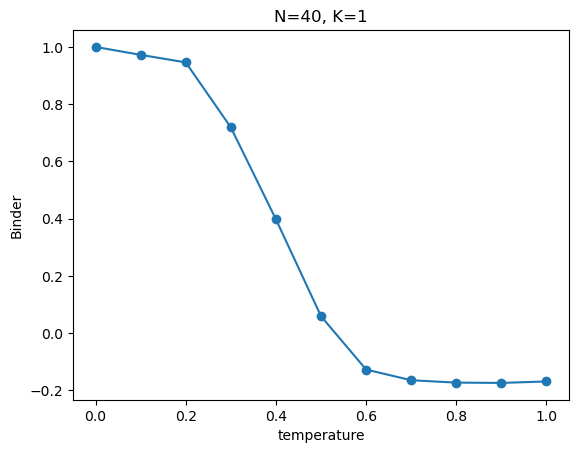

In [10]:
plt.plot(T_vals, U[:,2], marker='o')
plt.xlabel('temperature')
plt.ylabel('Binder')
plt.title('N=40, K=1')

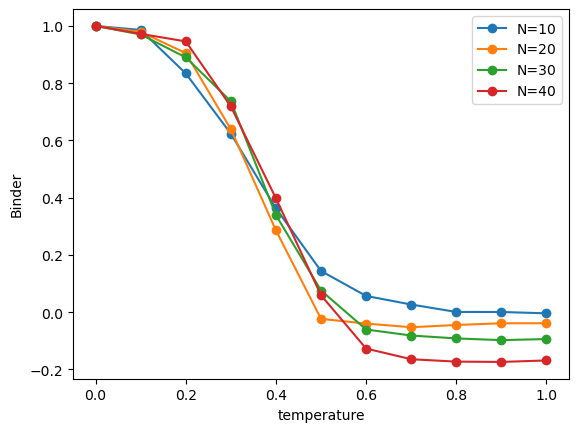

In [10]:
T_vals = np.load('data/N10_K1_S1/T_vals.npy')
# plt.plot(T_vals, np.load('data/N5_K1_S1/Uq.npy')[:,2], marker='o', label='N=5')
plt.plot(T_vals, np.load('data/N10_K1_moreSamples_S1/U.npy')[:,2], marker='o', label='N=10')
# plt.plot(T_vals, np.load('data/N15_K1_S1/U.npy')[:,2], marker='o', label='N=15')
plt.plot(T_vals, np.load('data/N20_K1_moreSamples_S1/U.npy')[:,2], marker='o', label='N=20')
# plt.plot(T_vals, np.load('data/N25_K1_moreSamples_S1/U.npy')[:,2], marker='o', label='N=25')
plt.plot(T_vals, np.load('data/N30_K1_moreSamples_S1/U.npy')[:,2], marker='o', label='N=30')
plt.plot(T_vals, np.load('data/N40_K1_moreSamples_S1/U.npy')[:,2], marker='o', label='N=40')
plt.legend()
plt.xlabel('temperature')
plt.ylabel('Binder')
plt.savefig('Binder_moreThermalSamples_lessReplica.png')

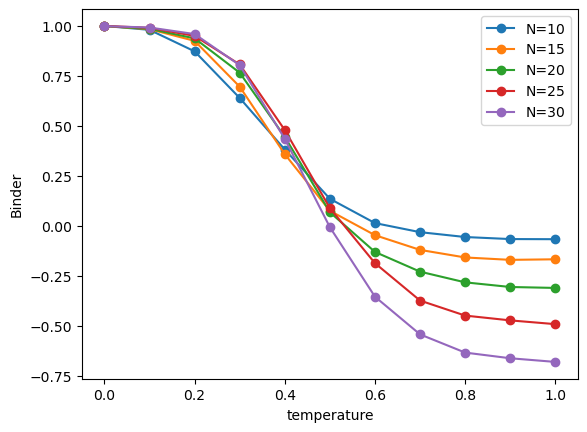

In [35]:
T_vals = np.load('data/N10_K1_S1/T_vals.npy')
# plt.plot(T_vals, np.load('data/N5_K1_S1/Uq.npy')[:,2], marker='o', label='N=5')
plt.plot(T_vals, np.load('data/N10_K1_S1/U.npy')[:,2], marker='o', label='N=10')
plt.plot(T_vals, np.load('data/N15_K1_S1/U.npy')[:,2], marker='o', label='N=15')
plt.plot(T_vals, np.load('data/N20_K1_S1/U.npy')[:,2], marker='o', label='N=20')
plt.plot(T_vals, np.load('data/N25_K1_S1/U.npy')[:,2], marker='o', label='N=25')
plt.plot(T_vals, np.load('data/N30_K1_S1/U.npy')[:,2], marker='o', label='N=30')
plt.legend()
plt.xlabel('temperature')
plt.ylabel('Binder')
plt.savefig('Binder_lessThermalSamples.png')

# Scratch

In [26]:
T_vals = np.load('data/N20_K1_highT_S1/T_vals.npy')
U = np.load('data/N20_K1_highT_S1/U.npy')

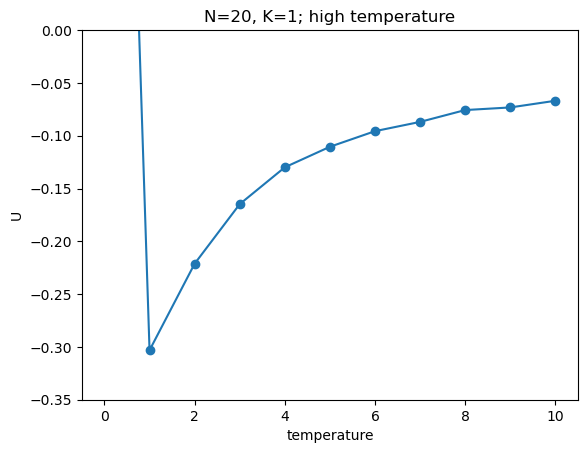

In [32]:
plt.plot(T_vals[:], U[:,2], marker='o')
plt.ylim(-0.35,0)
plt.title('N=20, K=1; high temperature')
plt.xlabel('temperature')
plt.ylabel('U')
plt.savefig('Binder_highTemp.png')